Matplotlib is building the font cache; this may take a moment.


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

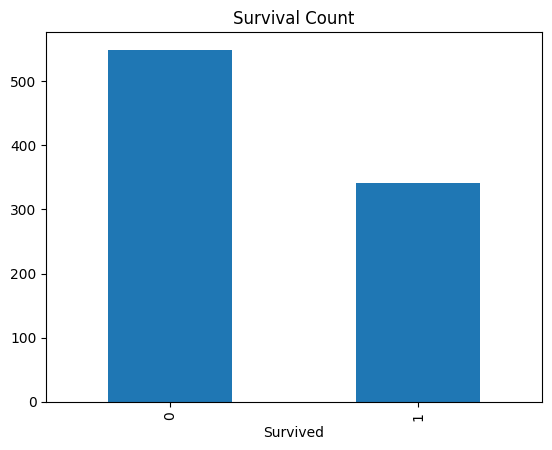

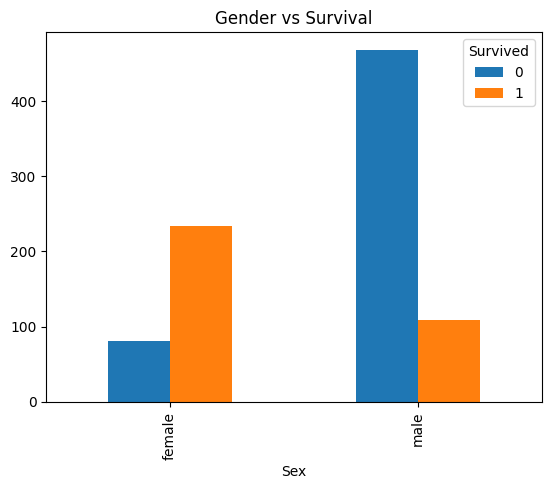

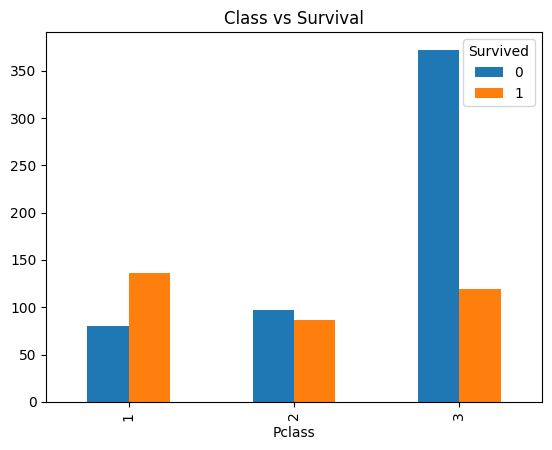

/var/folders/mn/csl87qt12933ndjr9_z2sj100000gn/T/ipykernel_14296/4023611180.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].mean(), inplace=True)
/var/folders/mn/csl87qt12933ndjr9_z2sj100000gn/T/ipykernel_14296/4023611180.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

Logistic Regression Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Decision Tree Accuracy: 0.7988826815642458
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.78       179
weighted avg       0.80      0.80      0.79       179

Random Forest Accuracy: 0.8268156424581006
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       105
           1       0.82      0.74      0.78        74

    accuracy                           0.83    

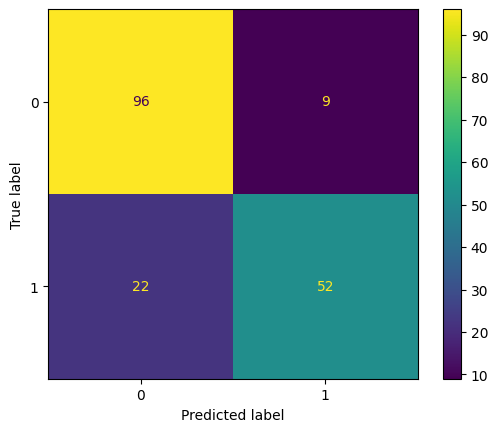

                 Model  Accuracy
0  Logistic Regression  0.810056
1        Decision Tree  0.798883
2        Random Forest  0.826816


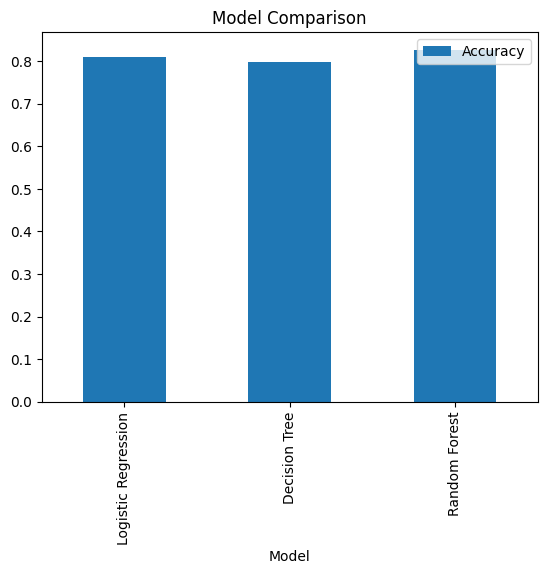

Submission file created!


In [1]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ===============================
# 2. Load Dataset
# ===============================
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.head())
print(train.info())

# ===============================
# 3. EDA (Exploratory Data Analysis)
# ===============================

# Survival count
train['Survived'].value_counts().plot(kind='bar', title='Survival Count')
plt.show()

# Gender vs survival
pd.crosstab(train['Sex'], train['Survived']).plot(kind='bar', title='Gender vs Survival')
plt.show()

# Class vs survival
pd.crosstab(train['Pclass'], train['Survived']).plot(kind='bar', title='Class vs Survival')
plt.show()

# ===============================
# 4. Data Preprocessing
# ===============================

# Fill missing values
train['Age'].fillna(train['Age'].mean(), inplace=True)
test['Age'].fillna(test['Age'].mean(), inplace=True)

train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)
test['Fare'].fillna(test['Fare'].mean(), inplace=True)

# Encode categorical variables
le = LabelEncoder()
train['Sex'] = le.fit_transform(train['Sex'])
test['Sex'] = le.transform(test['Sex'])

train = pd.get_dummies(train, columns=['Embarked'], drop_first=True)
test = pd.get_dummies(test, columns=['Embarked'], drop_first=True)

# Feature Engineering
train['FamilySize'] = train['SibSp'] + train['Parch']
test['FamilySize'] = test['SibSp'] + test['Parch']

# Drop unnecessary columns
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
train.drop(columns=drop_cols, inplace=True)
test_ids = test['PassengerId']
test.drop(columns=drop_cols, inplace=True)

# ===============================
# 5. Split Data
# ===============================
X = train.drop('Survived', axis=1)
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# ===============================
# 6. Model 1: Logistic Regression
# ===============================
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_val)

print("Logistic Regression Accuracy:", accuracy_score(y_val, y_pred_log))
print(classification_report(y_val, y_pred_log))

# ===============================
# 7. Model 2: Decision Tree
# ===============================
dt_model = DecisionTreeClassifier(max_depth=5)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_val)

print("Decision Tree Accuracy:", accuracy_score(y_val, y_pred_dt))
print(classification_report(y_val, y_pred_dt))

# ===============================
# 8. Model 3: Random Forest
# ===============================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

# ===============================
# 9. Hyperparameter Tuning (Random Forest)
# ===============================
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [4, 6, 8]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_val)

print("Tuned Random Forest Accuracy:", accuracy_score(y_val, y_pred_best))

# ===============================
# 10. Confusion Matrix
# ===============================
cm = confusion_matrix(y_val, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# ===============================
# 11. Model Comparison
# ===============================
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_val, y_pred_log),
        accuracy_score(y_val, y_pred_dt),
        accuracy_score(y_val, y_pred_rf)
    ]
})

print(results)

results.set_index('Model').plot(kind='bar', title='Model Comparison')
plt.show()

# ===============================
# 12. Predict Test Data
# ===============================
final_predictions = best_rf.predict(test)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': final_predictions
})

submission.to_csv('submission.csv', index=False)

print("Submission file created!")